In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

In [46]:
# Manipulation des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration esthétique (facultatif)
sns.set(style="whitegrid")

# Affichage des graphiques dans le notebook (si tu es dans Jupyter)
%matplotlib inline


In [47]:
!pip install scipy



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
# Statistiques avancées
from scipy import stats


In [ ]:
# on commence par tempo

In [10]:
chemin = r"C:\Users\gaell\OneDrive\WILD CODE SCHOOL\Projet 2 music SPOTIFY\SpotifyFeatures.csv"
df = pd.read_csv(chemin)
df.head()



,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [11]:
# Statistiques descriptives
df['tempo'].describe()

# Valeurs manquantes
df['tempo'].isnull().sum()


np.int64(0)

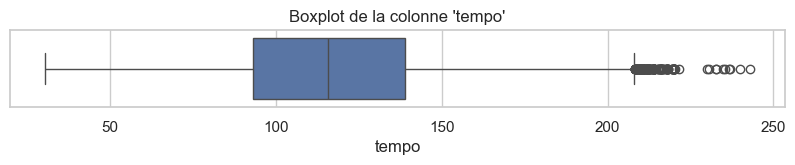

In [12]:
plt.figure(figsize=(10, 1))
sns.boxplot(x=df['tempo'])
plt.title("Boxplot de la colonne 'tempo'")
plt.show()


In [13]:
# Calcul des bornes IQR
Q1 = df['tempo'].quantile(0.25)
Q3 = df['tempo'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Borne basse : {lower_bound:.2f}")
print(f"Borne haute : {upper_bound:.2f}")


Borne basse : 23.82
Borne haute : 208.20


In [ ]:
#Cela signifie que toutes les valeurs de tempo en dehors de cet intervalle sont considérées comme des outliers (valeurs aberrantes).

In [14]:
outliers_tempo = df[(df['tempo'] < 23.82) | (df['tempo'] > 208.20)]
print(f"Nombre d'outliers dans 'tempo' : {len(outliers_tempo)}")


Nombre d'outliers dans 'tempo' : 167


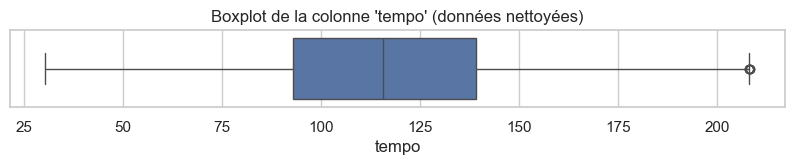

In [15]:
# on clean en gardant les valeurs entre les bornes
df_clean_tempo = df[(df['tempo'] >= 23.82) & (df['tempo'] <= 208.20)]
# Visualisation des données nettoyées
plt.figure(figsize=(10, 1))
sns.boxplot(x=df_clean_tempo['tempo'])
plt.title("Boxplot de la colonne 'tempo' (données nettoyées)")
plt.show()


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

In [17]:
df_clean_tempo = df_clean_tempo.dropna(subset=['tempo'])
# Vérification des valeurs manquantes après nettoyage

In [18]:
print(f"Taille initiale : {len(df)}")
print(f"Taille après nettoyage : {len(df_clean_tempo)}")
# Visualisation des données nettoyées
plt.figure(figsize=(10, 1))             

Taille initiale : 232725
Taille après nettoyage : 232558


<Figure size 1000x100 with 0 Axes>

<Figure size 1000x100 with 0 Axes>

In [20]:
# on regarde le dernier time signature
df['time_signature'].describe()

count     232725
unique         5
top          4/4
freq      200760
Name: time_signature, dtype: object

In [21]:
#il faut regarder quel type pour le time signature
df['time_signature'].unique()

array(['4/4', '5/4', '3/4', '1/4', '0/4'], dtype=object)

In [22]:
#il faut changer le format de time signature en int mais il faut visulaiser avant
plt.figure(figsize=(10, 1)) 

<Figure size 1000x100 with 0 Axes>

<Figure size 1000x100 with 0 Axes>

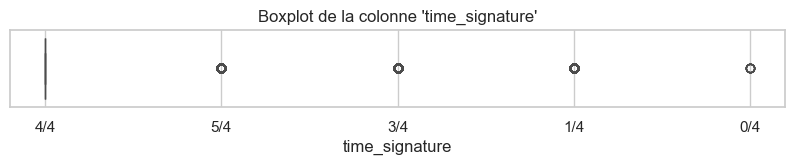

In [23]:
plt.figure(figsize=(10, 1))
sns.boxplot(x=df['time_signature'])
plt.title("Boxplot de la colonne 'time_signature'")
plt.show()


In [24]:
%matplotlib inline


In [26]:
df['time_signature'].dtype


dtype('O')

In [27]:
#converstion en numerique   
df['time_signature'] = pd.to_numeric(df['time_signature'], errors='coerce')
# Vérification du type après conversion
df['time_signature'].dtype

dtype('float64')

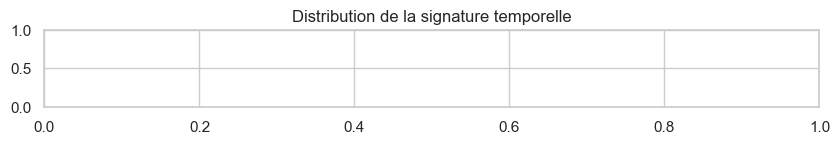

In [28]:
df = df.dropna(subset=['time_signature'])
# Visualisation des données nettoyées
plt.figure(figsize=(10, 1))
sns.boxplot(x='time_signature', data=df)
plt.title("Distribution de la signature temporelle")
plt.show()

In [29]:
df['time_signature'].dtype  # devrait maintenant être float64


dtype('float64')

In [30]:
Q1 = df['time_signature'].quantile(0.25)
Q3 = df['time_signature'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Borne basse : {lower_bound}")
print(f"Borne haute : {upper_bound}")
# Cela signifie que toutes les valeurs de time_signature en dehors de cet intervalle sont considérées comme des outliers (valeurs aberrantes).

Borne basse : nan
Borne haute : nan


In [31]:
print("Valeurs uniques dans time_signature :")
print(df['time_signature'].value_counts(dropna=False).sort_index())

print("\nNombre de valeurs non nulles :", df['time_signature'].notnull().sum())


Valeurs uniques dans time_signature :
Series([], Name: count, dtype: int64)

Nombre de valeurs non nulles : 0


In [49]:
df = pd.read_csv("TON_CHEMIN_VERS_SpotifyFeatures.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'TON_CHEMIN_VERS_SpotifyFeatures.csv'

In [33]:
chemin = r"C:\Users\gaell\OneDrive\WILD CODE SCHOOL\Projet 2 music SPOTIFY\SpotifyFeatures.csv"
df = pd.read_csv(chemin)


In [34]:
df = pd.read_csv(chemin, usecols=['time_signature'])


In [35]:
df['time_signature'].unique()


array(['4/4', '5/4', '3/4', '1/4', '0/4'], dtype=object)

In [36]:
#Extraire uniquement le numérateur de la signature (4, 5, 3, etc.) pour en faire une colonne numérique propre.
# Étape 1 : Extraire la partie avant le '/' et la convertir en entier
df['time_signature_clean'] = df['time_signature'].str.extract(r'^(\d+)').astype('Int64')

# Étape 2 : Aperçu des valeurs uniques
print(df['time_signature_clean'].value_counts(dropna=False).sort_index())

# Étape 3 : Remplacer l’ancienne colonne si tu veux
df['time_signature'] = df['time_signature_clean']
df.drop(columns='time_signature_clean', inplace=True)


time_signature_clean
0         8
1      2608
3     24111
4    200760
5      5238
Name: count, dtype: Int64


In [ ]:
#je supprime les valeurs aberrantes 0 Impossible en musique → à supprimer
#  et 1 Musicalement peu plausible → probablement une erreur de parsing ou un tag incohérent

In [37]:
df = df[df['time_signature'].isin([3, 4, 5])]
# on garde donc 3 4 et 5

In [38]:
#on verifie les valeurs uniques restantes
df['time_signature'].value_counts().sort_index()


time_signature
3     24111
4    200760
5      5238
Name: count, dtype: Int64

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 230109 entries, 0 to 232724
Data columns (total 1 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   time_signature  230109 non-null  Int64
dtypes: Int64(1)
memory usage: 3.7 MB


In [41]:
df.head()

,time_signature
0,4
1,4
2,5
3,4
4,4


In [44]:
df

,time_signature
0,4
1,4
2,5
3,4
4,4
...,...
232720,4
232721,4
232722,4
232723,4


In [3]:
df

NameError: name 'df' is not defined